In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)',"petal width (cm)"]].values
y = (iris.target == 0)  

per_clf = Perceptron(random_state=42)
per_clf.fit(X,y)

X_new = [[2,0.5],[3,1]]
y_pred = per_clf.predict(X_new)
y_pred

In [ ]:
# from sklearn.datasets import fetch_california_housing
# from sklearn.metrics import root_mean_squared_error
# from sklearn.model_selection import train_test_split
# from sklearn.neural_network import MLPRegressor
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler

# housing = fetch_california_housing()
# X_train_full,X_test,y_train_full,y_test = train_test_split(housing.data,housing.target,random_state=42)
# X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full,random_state=42)

# mlp_reg = MLPRegressor(hidden_layer_sizes=[50,50,50],random_state=42)
# pipeline = make_pipeline(StandardScaler(),mlp_reg)
# pipeline.fit(X_train,y_train)
# y_pred = pipeline.predict(X_valid)
# rmse = root_mean_squared_error(y_valid,y_pred)
# rmse

In [ ]:
import tensorflow as tf
import keras
fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full,Y_train_full) , (X_test,Y_test) = fashion_mnist
X_train,Y_train = X_train_full[:-5000],Y_train_full[:-5000]
X_valid,Y_valid = X_train_full[-5000:],Y_train_full[-5000:]

In [ ]:
X_train.shape

In [ ]:
X_train.dtype

In [ ]:
X_train,X_valid,X_test = X_train / 255 , X_valid / 255 , X_test / 255

In [ ]:
class_names = ['T-shirt / top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle-Boot']

In [ ]:
class_names[Y_train[16]]

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape = [28,28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300,activation = 'relu'))
model.add(tf.keras.layers.Dense(100,activation = 'relu'))
model.add(tf.keras.layers.Dense(10,activation = 'softmax'))

In [ ]:
model.summary()

In [ ]:
# model = tf.keras.Sequential([
#     tf.keras.layers.Flatten(input_shape = [28,28]),
#     tf.keras.layers.Dense(300,activation='relu'),
#     tf.keras.layers.Dense(100,activation='relu'),
#     tf.keras.layers.Dense(10,activation = 'softmax')
# ])

In [ ]:
keras.utils.plot_model(model,show_shapes=True)

In [ ]:
model.layers

In [ ]:
hidden1 = model.layers[1]
hidden1.name

weights,biases = hidden1.get_weights()
weights

In [ ]:
weights.shape

In [ ]:
biases.shape

In [ ]:
biases

In [ ]:
model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate=0.002),
              metrics = ['accuracy'])

In [ ]:
Y_hot_train = tf.keras.utils.to_categorical(Y_train) # Used for one hot encoding

In [ ]:
np.argmax(Y_hot_train,axis = 1) # for converting one-hot encoded labels into simple implementations

In [ ]:
history = model.fit(X_train,Y_train,epochs = 30,validation_data = (X_valid,Y_valid))

In [ ]:
history.params

In [ ]:
history.epoch

In [ ]:
history.history

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8,5),xlim = [0,30],ylim = [0,1],grid = True,xlabel='epoch',style = ['r--','r--','b-','b-*']
)
plt.show()

In [ ]:
model.evaluate(X_test,Y_test)

In [ ]:
X_new = X_test[:3]

In [ ]:
y_proba = model.predict(X_new)

In [ ]:
y_proba.round(2)

In [ ]:
y_pred = y_proba.argmax(axis = 1)
y_pred

In [ ]:
import numpy as np
np.array(class_names)[y_pred]

In [ ]:
tf.random.set_seed(42)

In [ ]:
norm_layer = keras.layers.Normalization(input_shape = X_train.shape[1:])
model = keras.Sequential([
    norm_layer,
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss = 'mse',optimizer = optimizer, metrics = ['RootMeanSquaredError'])
norm_layer.adapt(X_train)

history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid))
mse_test,rmse_test = model.evaluate(X_test,Y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

In [ ]:
model.summary()

In [ ]:
model.layers

In [ ]:
X_train.shape

In [ ]:
_ = X_train

In [ ]:
normalization_layer = keras.layers.Normalization()
hidden_layer_1 = keras.layers.Dense(30,activation='relu')
hidden_layer_2 = keras.layers.Dense(30,activation='relu')
concat_layer = keras.layers.Concatenate()
output_layer = keras.layers.Dense(1)

input_ = keras.layers.Input(shape = _.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer_1(normalized)
hidden2 = hidden_layer_2(hidden1)
concat = concat_layer([hidden2,normalized])
output_ = output_layer(concat)

model = keras.Model(inputs = [input_],outputs = [output_])
# Next we complie the model , adapt the normalization layer and then fit and evaluate and then predict                                         

In [ ]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

In [ ]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
# model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

# X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
# X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
# X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
# X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

In [ ]:
print("X_train_wide shape:", X_train_wide.shape)
print("X_train_deep shape:", X_train_deep.shape)
print("Sample of X_train_wide data:", X_train_wide[0])

In [ ]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), Y_train, epochs=20,
                    validation_data=((X_valid_wide, X_valid_deep), Y_valid))
mse_test = model.evaluate((X_test_wide, X_test_deep), Y_test)
y_pred = model.predict((X_new_wide, X_new_deep))

In [ ]:
input_wide = keras.layers.Input(shape = [5])
input_deep = keras.layers.Input(shape = [6])

norm_layer_wide = keras.layers.Normalization()
norm_layer_deep = keras.layers.Normalization()

norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

hidden1 = keras.layers.Dense(30,activation='relu')(norm_deep)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
# concat = keras.layers.concatenate([norm_wide,hidden2]) # Can write below line as this too
concat = keras.layers.Concatenate()([norm_wide,hidden2])
output = keras.layers.Dense(1)(concat)

model = keras.Model(inputs = [input_wide,input_deep], outputs = [output])

In [ ]:
# optimizers = keras.optimizers.Adam(learning_rate=0.01)
# model.compile(optimizer=optimizers,loss = keras.losses.mean_squared_error,metrics = ['RootMeanSquaredError'])
# X_train_wide,X_train_deep = X_train[:,:5] , X_train[:,2:]
# X_valid_wide,X_valid_deep = X_valid[:,:5], X_valid[:,:5]
# X_test_wide,X_test_deep = X_test[:,:5], X_test[:,2:]
# X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

# norm_layer_wide.adapt(X_train_wide)
# norm_layer_deep.adapt(X_train_deep)

# history = model.fit({'input_wide':X_train_wide,'input_deep':X_train_deep},Y_train,epochs = 20,validation_data=((X_valid_wide,X_valid_deep),Y_valid))
# mse_test = model.evaluate((X_test_wide,X_test_deep),Y_test)
# y_pred = model.predict((X_new_wide,X_new_deep))

# history = model.fit()

In [ ]:
X_train = _

In [ ]:
X_train.shape

In [ ]:
class WideAndDeepModel(keras.Model):
    def __init__(self,units = 30, activation = 'relu', **kwargs):
        super().__init__(**kwargs) # Necceasy for keyword arguments like names
        self.norm_layer_wide = keras.layers.Normalization()
        self.norm_layer_deep = keras.layers.Normalization()
        self.hidden1 = keras.layers.Dense(units,activation=activation)
        self.hidden2 = keras.layers.Dense(units,activation=activation)
        self.concat_layer = keras.layers.Concatenate()
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)
    
    def call(self,inputs):
        input_wide,input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = self.concat_layer([hidden2,norm_wide])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output,aux_output
        

In [ ]:
model = WideAndDeepModel(units = 40,activation='relu',name = 'my_cool_model')
model.compile()

In [ ]:
model.save('my_keras_model.keras')

In [ ]:
norm_layer = keras.layers.Normalization(input_shape = X_train.shape[1:])
model = keras.Sequential([
    norm_layer,
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss = 'mse',optimizer = optimizer, metrics = ['RootMeanSquaredError'])
norm_layer.adapt(X_train)

# mse_test,rmse_test = model.evaluate(X_test,Y_test)
# X_new = X_test[:3]
# y_pred = model.predict(X_new)

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_checkpoint.weights.h5",save_best_only=True,save_weights_only=True)
history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid),callbacks=[checkpoint_cb])

In [ ]:
early_cb = keras.callbacks.EarlyStopping(patience=1,verbose=1)
history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid),callbacks=[early_cb])

In [ ]:
history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid),callbacks=[early_cb,checkpoint_cb])

In [ ]:
class PrintVaLTrainingRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # return super().on_epoch_end(epoch, logs)
        ratio = logs['val_loss'] / logs['loss']
        print(f'epoch = {epoch} , val/train = {ratio:.2f}')

In [ ]:
from pathlib import Path
from time import strftime
# Created directories based on time
def get_run_logdir(root_log_dir = 'my_logs'):
    return Path(root_log_dir) / strftime('run_%y_%m_%d_%H_%M_%S')

In [ ]:
run_log_dir = get_run_logdir(r'C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\run_logs')
tensorboard_cb = keras.callbacks.TensorBoard(run_log_dir,profile_batch=(100,200))

norm_layer = keras.layers.Normalization(input_shape = X_train.shape[1:])
model = keras.Sequential([
    norm_layer,
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=0.002)
model.compile(loss = 'mse',optimizer = optimizer, metrics = ['RootMeanSquaredError'])
norm_layer.adapt(X_train)

# mse_test,rmse_test = model.evaluate(X_test,Y_test)
# X_new = X_test[:3]
# y_pred = model.predict(X_new)
history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid),callbacks=[tensorboard_cb])

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir=./run_logs/

In [ ]:
import keras_tuner as kt

def build_model(hp : kt.HyperParameters) -> keras.Model:
    n_hidden = hp.Int('n_hidden',min_value = 0, max_value = 8, default = 4)
    n_neuorns = hp.Int('n_neurons',min_value = 16, max_value = 256)
    learning_rate = hp.Float('learning_rate',min_value = 1e-4,max_value = 1e-1, sampling='log')
    optimizer = hp.Choice('optimizer',values=['sgd','adam'])

    if optimizer == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model = keras.Sequential()
    model.add(keras.layers.Flatten())

    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neuorns,activation='relu'))

    model.add(keras.layers.Dense(10,activation='relu'))
    model.compile(loss = 'sparse_categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

    return model

In [ ]:
random_search_tuner = kt.RandomSearch(build_model,objective = 'val_accuracy',max_trials=5,overwrite = True,directory = 'my_fashion_mnist',project_name = 'my_rnd_search',seed = 42)

random_search_tuner.search(X_train,Y_train,epochs = 10,validation_data = (X_valid,Y_valid))

In [ ]:
top_3_models = random_search_tuner.get_best_models(num_models=3)

In [ ]:
best_model = top_3_models[0]
best_model

In [ ]:
top_3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top_3_params[0].values

In [ ]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

In [ ]:
best_trial.metrics.get_last_value('val_accuracy')

In [ ]:
best_model.fit(X_train,Y_train,epochs=10)
test_loss,test_accuracy = best_model.evaluate(X_test,Y_test)

In [ ]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp) -> keras.Model:
        return build_model(hp)
    
    def fit(self, hp : kt.HyperParameters, model, X,Y,*args, **kwargs):
        if hp.Boolean('normalize'):
            norm_layer = keras.layers.Normalization()
            X = norm_layer(X)

        return model.fit(X,Y,*args,**kwargs)

In [ ]:
def func(*args):
    return np.array(args).mean()

func(0,1,2,3,4,5,6,7,8,9,10)

In [ ]:
hyperband_tuner = kt.Hyperband(MyClassificationHyperModel(),objective='val_accuracy',seed = 42, max_epochs = 10, factor = 3, hyperband_iterations = 2, overwrite = True, directory = 'my_fashion_mnist', project_name = 'hyperband')

In [ ]:
root_logdir = Path(hyperband_tuner.project_dir) / 'tensorboard'
tensorboard_cb = keras.callbacks.TensorBoard(root_logdir)
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 2)
hyperband_tuner.search(X_train,Y_train,epochs = 10,validation_data = (X_valid,Y_valid),callbacks = [early_stopping_cb,tensorboard_cb])

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir=./my_fashion_mnist/hyperband/tensorboard/

## Exercise Solutions from question 3 to 10
1. Done
2. Drawn in book 

3. Because a perceptron is not able to output probabilities of a class occuring inside it , also a perceptron doesnt have robust regularization as in the case of logistic regression , instead it stops training when no more errors can be made on the training data.To make it equivalent to a logistic regression classifier , replace the activation function with a sigmoid function (or the softmax activation function) , if there are multiple neurons , as softmax is designed for multi-classs classification and sigmoid is used for binary classsification, train it using gradient descent and then minimize the cost function (cross-entropy) using gradient descent , it acts like a logistic regression classifier.

4. The first MLP's followed a step function which is a  np.heavside() , it had linear differentiation and gradient descent cannot work on flat surfaces as there is no slope differentiation is zero , so gradient is zero , and was not able to capture complex patterns ,sigmoid activation function was adopted because it had a non-zero differentiable function everywhere , allowing gradient descent to make progress everytime.

5. Three popular activation functions are Relu, tanh , sigmoid function , honorable mention gelu and Step function.(Plots below)

6. if passthrough neurons are neurons in input layer , then shape of input matrix X is (n,10) , where n is the rows and 10 are the features and columns, hidden layer's weight matrix shape is (n,10,50) , bias vector shape is (50,) output layer's weight matrix shape is (n,50,3) bias vector will be (3,), output matrix shape will be (n,3)  

7. we need 2 neurons as it is a binary classification task, we should use to sigmoid activation function , for MNIST as it is multi-class 10 neurons + softmax activation function , softmax activation function will be used , for getting to predict house price only 1 neuron will be used , and the activation function can either be a Relu , if no negative values are allowed or no activation or linear function is fine for regression tasks.

8. backpropogation is the process by which weights and biases are reorganized by gradient descent to minimize the loss , reverse-mode autodiff is used to calculate gradients using differentiation done with the help of computaation graph during backpropogation.

9. We can tweak the number of hidden layers , numbers of neurons in each hidden layer , learning rate , batch size , loss function , method of optimization(SGD or adam), activation function choice (these are all hyper-parameters that can be tweaked), if overfitting is happening we can implement regularization techniques or we can lessen the number of hidden layers and neurons

10. Done below - below 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_vals = np.arange(-5, 5, step=0.1)
e_x = np.exp(X_vals)
e_minus_x = np.exp(-X_vals)

tan_h = (e_x - e_minus_x) / (e_x + e_minus_x)
relu = np.maximum(0, X_vals)
sigmoid = 1 / (1 + np.exp(-X_vals))
heavside = np.heaviside(X_vals, 1)

plt.plot(X_vals, tan_h, 'g', label='tanh')
plt.plot(X_vals, relu, 'b', label='ReLU')
plt.plot(X_vals, sigmoid, 'r--', label='Sigmoid')
plt.plot(X_vals, heavside, 'y', label='Heaviside')

plt.xlabel('x_values')
plt.ylabel('Activation output')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from keras.datasets.mnist import load_data

(X_train,Y_train), (X_test,Y_test) = load_data() # loading training and test set

X_test = X_test / 255
X_train,Y_train,X_valid,Y_valid = X_train[:50000] / 255  ,Y_train[:50000] ,X_train[50000:] / 255 ,Y_train[50000:] # split into training validation set


run_index = 1 # increment this at every run
run_logdir = Path() / "my_mnist_logs" / "run_{:03d}".format(run_index)
run_logdir


# Re-Training on updated Learning Rate

norm_layer = keras.layers.Normalization()
model = keras.Sequential([
    keras.layers.Input(shape = (28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation='relu'),
    keras.layers.Dense(200,activation='relu'),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(10,activation=keras.activations.softmax)
])

norm_layer.adapt(X_train)
optimizer = keras.optimizers.SGD(learning_rate=3e-1)
model.compile(loss = 'sparse_categorical_crossentropy',optimizer=optimizer,metrics=[keras.metrics.sparse_categorical_accuracy])
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

history = model.fit(X_train, Y_train, epochs=100,
                    validation_data=(X_valid, Y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

In [ ]:
model = tf.keras.models.load_model("my_mnist_model.keras") # rollback to best model
model.evaluate(X_test, Y_test)

In [ ]:
%tensorboard --logdir=./my_mnist_logs

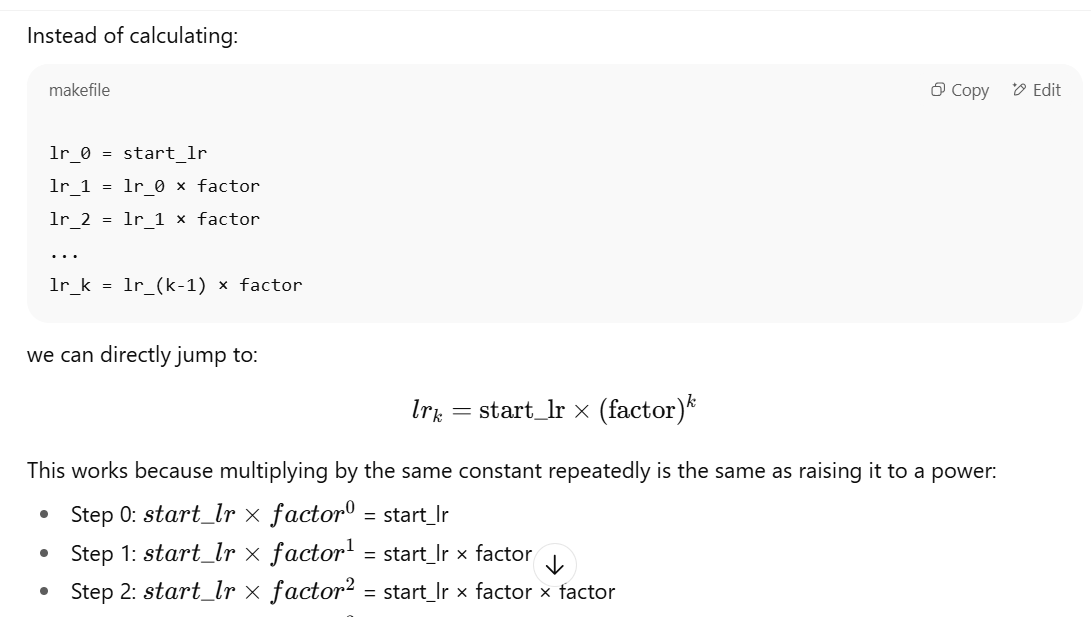

In [ ]:
class Learning_rate_sweep(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self,initial_learning_rate,start_lr,end_lr,total_steps):
        self.initial_learning_rate = initial_learning_rate
        self.start_lr = start_lr
        self.end_lr = end_lr
        self.total_steps = total_steps
        self.factor = (end_lr / start_lr) ** (1 / total_steps)
    
    def __call__(self, step):
        return self.start_lr * (self.factor ** step)
    
class Learning_rate_batch_loss_callback(keras.callbacks.Callback):
    def __init__(self):
        self.lrs = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate
        if callable(lr):
            step = self.model.optimizer.iterations
            lr = lr(step)
        # if lr is tensor, convert to float
        if isinstance(lr, tf.Tensor):
            lr = lr.numpy()
        self.lrs.append(float(lr))
        self.losses.append(logs["loss"])


In [ ]:
Learning_rate_sweep(0.01,0.001,0.1,400)(10) # For step 10

In [ ]:
norm_layer = keras.layers.Normalization()
model = keras.Sequential([
    keras.layers.Input(shape = (28,28)),
    norm_layer,
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation='relu'),
    keras.layers.Dense(200,activation='relu'),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(10,activation=keras.activations.softmax)
])

norm_layer.adapt(X_train)
optimizer = keras.optimizers.SGD(Learning_rate_sweep(1e-3,1e-3,1,1520))
model.compile(loss = 'sparse_categorical_crossentropy',optimizer=optimizer,metrics=[keras.metrics.sparse_categorical_accuracy])
callback = keras.callbacks.EarlyStopping(patience=3,verbose=True,monitor='val_sparse_categorical_accuracy',mode = 'max')


In [ ]:
lr_logger = Learning_rate_batch_loss_callback()
history = model.fit(X_train,Y_train,epochs = 1,validation_data=(X_valid,Y_valid),callbacks=[callback,lr_logger],batch_size=32) # Trained only for 1 epoch becuase 50000 images and batch size 32 means learning rate updated 1525 times for each batch

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(lr_logger.lrs, lr_logger.losses)

lr_logger.losses = np.clip(lr_logger.losses,0,3)
plt.xscale('log')              # Learning rates are better viewed on a log scale
plt.axhline(min(lr_logger.losses), color='red', linestyle='--', linewidth=0.8)
# plt.ylim(top=10)
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.title('Learning Rate Finder')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
min_loss_idx = np.argmin(lr_logger.losses)
optimal_lr = lr_logger.lrs[min_loss_idx]
print(f"Optimal learning rate: {optimal_lr}, Minimum loss: {min(lr_logger.losses)}")
plt.show()


In [ ]:
0.4412733316421509 / 2

In [ ]:
history.history['val_loss']

In [ ]:
# Re-Training on updated Learning Rate

norm_layer = keras.layers.Normalization()
model = keras.Sequential([
    keras.layers.Input(shape = (28,28)),
    norm_layer,
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation='relu'),
    keras.layers.Dense(200,activation='relu'),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(10,activation=keras.activations.softmax)
])

norm_layer.adapt(X_train)
optimizer = keras.optimizers.SGD(learning_rate=3e-1)
model.compile(loss = 'sparse_categorical_crossentropy',optimizer=optimizer,metrics=[keras.metrics.sparse_categorical_accuracy])
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

history = model.fit(X_train, Y_train, epochs=100,
                    validation_data=(X_valid, Y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

In [ ]:
he_avg_init = keras.initializers.variance_scaling(scale = 2,mode='fan_avg',distribution='uniform')
dense = keras.layers.Dense(50,activation='sigmoid',kernel_initializer=he_avg_init)

In [ ]:
z = np.arange(-20.00,20.00,step = 0.001)
z

In [ ]:
alpha = 1
elu_activation = np.where(z < 0, alpha * (np.exp(z) - 1), z)
selu_activation = np.where(z < 0, 1.05 * (1.67 * (np.exp(z) - 1)),z)

In [ ]:
plt.plot(z,elu_activation,'g')
plt.plot(z,selu_activation,'r--')
# plt.ylim(top = 5)
plt.title('ELU activation')
plt.grid()
plt.show()

In [ ]:
(np.exp(-37) - 1)

In [ ]:
import seaborn as sns
# np.random.seed(43)
bell_distrib = np.random.normal(loc = 0,scale = 1, size = (100))
bell_distrib.sort()

bell_distrib_1_mean = bell_distrib * 1 + 1
bell_distrib_2_mean = bell_distrib * 2 + 0
bell_distrib_3_mean = bell_distrib * 3 + 0

sns.kdeplot(bell_distrib, label = f'{bell_distrib.mean():.2f} mean distrib')
sns.kdeplot(bell_distrib_1_mean,label = f'{bell_distrib_1_mean.mean():.2f} mean distrib')
sns.kdeplot(bell_distrib_2_mean,label = f'{bell_distrib_2_mean.mean():.2f} mean distrib')
sns.kdeplot(bell_distrib_3_mean,label = f'{bell_distrib_3_mean.mean():.2f} mean distrib')
def show_stats(name, arr):
    print(f"{name:20} Mean = {arr.mean():8.4f}  Std = {arr.std():8.4f}")

show_stats("bell_distrib", bell_distrib)
show_stats("bell_distrib_1_mean", bell_distrib_1_mean)
show_stats("bell_distrib_2_mean", bell_distrib_2_mean)
show_stats("bell_distrib_3_mean", bell_distrib_3_mean)
# plt.grid()
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
import keras

model = keras.Sequential([
    keras.layers.Input(shape = (28,28)),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300,activation='relu',kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100,activation='relu',kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10,activation='softmax')
])

In [ ]:
model.summary(expand_nested=True)

In [ ]:
import numpy as np
np.random.seed(42)
momentum = 0.9
v_hat = np.random.normal(size = (10)).mean()
new_v = 0.4
print(v_hat)
print((v_hat * momentum) + (new_v * (1-momentum)))

In [ ]:
model.layers

In [ ]:
from keras.datasets.mnist import load_data
from pathlib import Path
from time import strftime

(X_train,Y_train), (X_test,Y_test) = load_data() # loading training and test set

X_test = X_test / 255
X_train,Y_train,X_valid,Y_valid = X_train[:50000] / 255  ,Y_train[:50000] ,X_train[50000:] / 255 ,Y_train[50000:] # split into training validation set

def get_run_logdir(root_logdir = 'mnist_logs'):
    return Path(root_logdir) / strftime('run_%Y_%m_%d_%H_%M_%S')

# Re-Training on updated Learning Rate

norm_layer = keras.layers.Normalization()
model = keras.Sequential([
    keras.layers.Input(shape = (28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation='relu',kernel_initializer='he_normal'),
    keras.layers.Dense(200,activation='relu',kernel_initializer='he_normal'),
    keras.layers.Dense(100,activation='relu',kernel_initializer='he_normal'),
    keras.layers.Dense(10,activation=keras.activations.softmax)
])

norm_layer.adapt(X_train)
optimizer = keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss = 'sparse_categorical_crossentropy',optimizer=optimizer,metrics=[keras.metrics.sparse_categorical_accuracy])
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5)
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
run_logdir = get_run_logdir()
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

In [ ]:
history = model.fit(X_train, Y_train, epochs=200,
                    validation_data=(X_valid, Y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

In [ ]:
%load_ext tensorboard

In [68]:
%tensorboard --logdir=./mnist_logs/ 

Reusing TensorBoard on port 6007 (pid 23776), started 0:00:50 ago. (Use '!kill 23776' to kill it.)

In [ ]:
model.save('MNIST_model.keras',overwrite=True)

In [83]:
model_A = keras.saving.load_model('MNIST_model.keras')
model_A_clone = keras.models.clone_model(model_A) # This does not initialize weights
model_A_clone.set_weights(model_A.get_weights())

In [84]:
model_B_on_A : keras.Model = keras.Sequential(model_A.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1,activation = 'sigmoid'))

In [112]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

optimizer = keras.optimizers.SGD(learning_rate=0.01)
model_B_on_A.compile(loss = 'binary_crossentropy',optimizer=optimizer,metrics = ['accuracy'])

In [113]:
model_B_on_A.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,901 (1.21 MB)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 315,800 (1.20 MB)

In [114]:
idx_6_7_X_train = X_train[(Y_train == 6) | (Y_train == 7)]
idx_6_7_X_test = X_test[(Y_test == 6) | (Y_test == 7)]
idx_6_7_X_valid = X_valid[(Y_valid == 6) | (Y_valid == 7)]
idx_6_7_Y_train = Y_train[(Y_train == 6) | (Y_train == 7)]
idx_6_7_Y_test = Y_test[(Y_test == 6) | (Y_test == 7)]
idx_6_7_Y_valid = Y_valid[(Y_valid == 6) | (Y_valid == 7)]


# Converts labels to 0 or 1 
idx_6_7_Y_train = (idx_6_7_Y_train == 7).astype(np.float32)
idx_6_7_Y_test  = (idx_6_7_Y_test == 7).astype(np.float32)
idx_6_7_Y_valid = (idx_6_7_Y_valid == 7).astype(np.float32)


In [115]:
idx_6_7_X_train.shape

(10126, 28, 28)

In [116]:
X_train.shape

(50000, 28, 28)

In [ ]:
history = model_B_on_A.fit(idx_6_7_X_train,idx_6_7_Y_train,epochs = 5,validation_data=(idx_6_7_X_valid,idx_6_7_Y_valid)) # For making the last layer somwhat sensible

Epoch 1/5
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5138 - loss: 1705.4896 - val_accuracy: 0.5299 - val_loss: 1358.1920
Epoch 2/5
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5136 - loss: 1329.2673 - val_accuracy: 0.5299 - val_loss: 1001.3619
Epoch 3/5
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5139 - loss: 950.1035 - val_accuracy: 0.5299 - val_loss: 644.5782
Epoch 4/5
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5163 - loss: 583.3781 - val_accuracy: 0.5299 - val_loss: 287.9073
Epoch 5/5
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5143 - loss: 219.1858 - val_accuracy: 0.8478 - val_loss: 14.2434


In [118]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = keras.optimizers.SGD(learning_rate=0.01)
model_B_on_A.compile(loss = 'binary_crossentropy',optimizer=optimizer,metrics = ['accuracy'])

In [120]:
model_B_on_A.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,901 (1.21 MB)

 Trainable params: 315,901 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [121]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=4)
tensorboard_cb = keras.callbacks.TensorBoard('binary_MNIST')
history = model_B_on_A.fit(idx_6_7_X_train,idx_6_7_Y_train,epochs = 200,validation_data=(idx_6_7_X_valid,idx_6_7_Y_valid),callbacks=[early_stopping_cb,tensorboard_cb])

Epoch 1/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9574 - loss: 15.8679 - val_accuracy: 0.9990 - val_loss: 0.0041
Epoch 2/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 0.9981 - val_loss: 0.0052
Epoch 3/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9997 - loss: 7.3021e-04 - val_accuracy: 0.9985 - val_loss: 0.0051
Epoch 4/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 6.9379e-04 - val_accuracy: 0.9995 - val_loss: 0.0011
Epoch 5/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 2.1401e-04 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 6/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 1.4265e-04 - val_accuracy: 0.9995 - val_loss: 9.5295e-04
Epoch 7/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 9.9276e-05 - val_accuracy: 0.9995 - val_loss: 0.0012
Epoch 8/200
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 

In [122]:
model_B_on_A.evaluate(idx_6_7_X_test,idx_6_7_Y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9970 - loss: 0.0107   


[0.007262497674673796, 0.9979858994483948]